# Book - Modern Time Series Forecasting with Python

## Chapter 07 - Exponential Smoothing Methods

### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.24.4
* statsmodels: 0.14.1
* sklearn: 1.3.2
* seaborn: 0.13.2


## Python Implemention of exponential smoothing

#### Loading libries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

import warnings
warnings.filterwarnings('ignore')

#### Load the Dataset

In [2]:
print("--- Load and Visualize AirPassengers Data ---")
try:
    # Use the pre-packaged AirPassengers dataset from statsmodels
    air_passengers_data = sm.datasets.get_rdataset("AirPassengers", "datasets", cache=True).data
    # Ensure proper datetime indexing
    air_passengers_data['year'] = air_passengers_data['time'].astype(int)
    air_passengers_data['month'] = ((air_passengers_data['time'] - air_passengers_data['year']) * 12 + 1).round().astype(int)
    air_passengers_data['date'] = pd.to_datetime(air_passengers_data['year'].astype(str) + '-' + air_passengers_data['month'].astype(str))
    air_passengers_series = air_passengers_data.set_index('date')['value']
    air_passengers_series.index.freq = 'MS'
except Exception as e:
    print(f"Error loading AirPassengers dataset: {e}")
    print("Using fallback data.")
    # Fallback data
    dates_fallback = pd.date_range(start='1949-01-01', periods=144, freq='MS')
    air_passengers_series = pd.Series(np.sin(np.linspace(0, 2*np.pi*12, 144)) * 50 + np.linspace(100, 500, 144) + np.random.normal(0, 20, 144), index=dates_fallback)



--- Load and Visualize AirPassengers Data ---


### <span style="color:blue">01. Simple exponential smoothing


#### Fit model

In [3]:
# Fit model
ses_model = SimpleExpSmoothing(air_passengers_series).fit(optimized=True)

print(ses_model.summary())


                       SimpleExpSmoothing Model Results                       
Dep. Variable:                  value   No. Observations:                  144
Model:             SimpleExpSmoothing   SSE                         163003.353
Optimized:                       True   AIC                           1016.567
Trend:                           None   BIC                           1022.506
Seasonal:                        None   AICC                          1016.854
Seasonal Periods:                None   Date:                 Sun, 07 Dec 2025
Box-Cox:                        False   Time:                         13:06:02
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9950000                alpha                 True
initial_level              112.00000                

#### Forecast 12 months

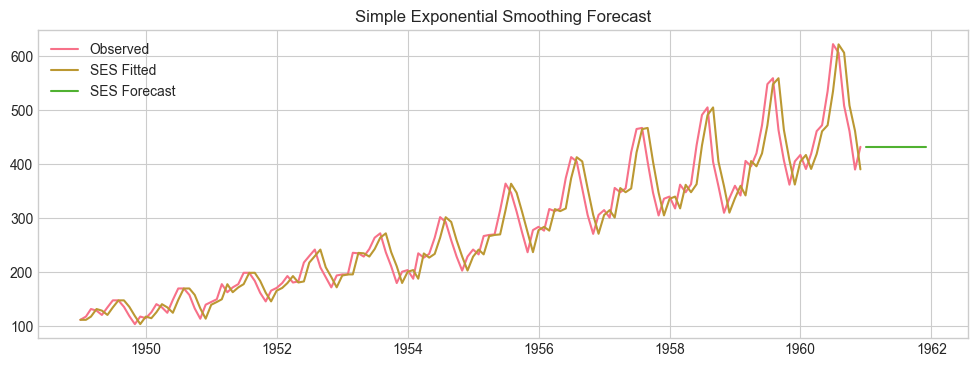

In [4]:
# Forecast 12 months
ses_forecast = ses_model.forecast(12)

# Plot
plt.figure(figsize=(12,4))
plt.plot(air_passengers_series, label="Observed")
plt.plot(ses_model.fittedvalues, label="SES Fitted")
plt.plot(ses_forecast, label="SES Forecast")
plt.legend()
plt.title("Simple Exponential Smoothing Forecast")
plt.show()

#### Residual Analysis

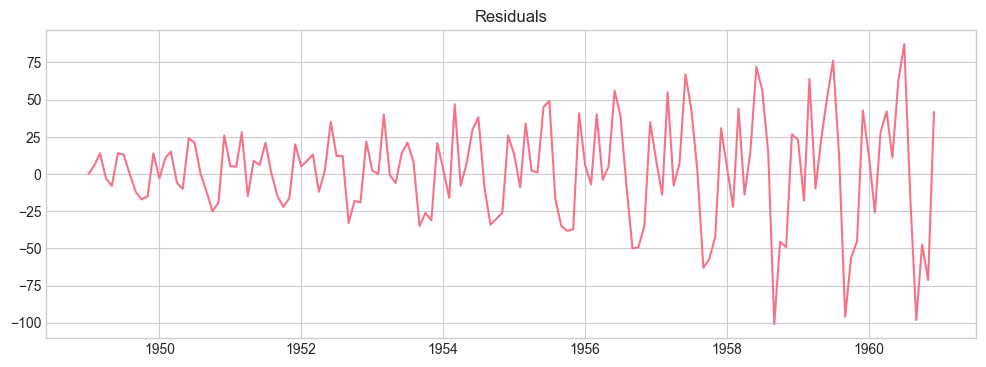

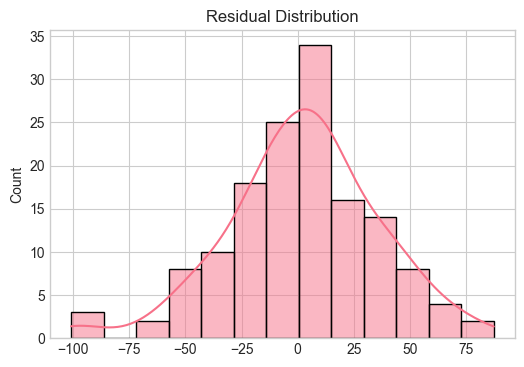

In [5]:
resid = ses_model.resid

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(resid, kde=True)
plt.title("Residual Distribution")
plt.show()


#### Evaluate model performance

In [6]:
mse = mean_squared_error(air_passengers_series, ses_model.fittedvalues)
mae = mean_absolute_error(air_passengers_series, ses_model.fittedvalues)

print("MSE:", mse)
print("MAE:", mae)

MSE: 1131.9677300429942
MAE: 25.715853004186183


### <span style="color:blue">02. Holt’s Additive Trend Model

#### a. Holt’s Additive Trend (Undamped)
##### When to use:
* Trend present, no seasonality, and you believe trend will continue linearly.

Holt's Additive Trend (Undamped)
                              Holt Model Results                              
Dep. Variable:                  value   No. Observations:                  144
Model:                           Holt   SSE                         164168.638
Optimized:                       True   AIC                           1021.592
Trend:                       Additive   BIC                           1033.472
Seasonal:                        None   AICC                          1022.206
Seasonal Periods:                None   Date:                 Sun, 07 Dec 2025
Box-Cox:                        False   Time:                         13:06:07
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9950187                alpha                 True
smoothing_trend    

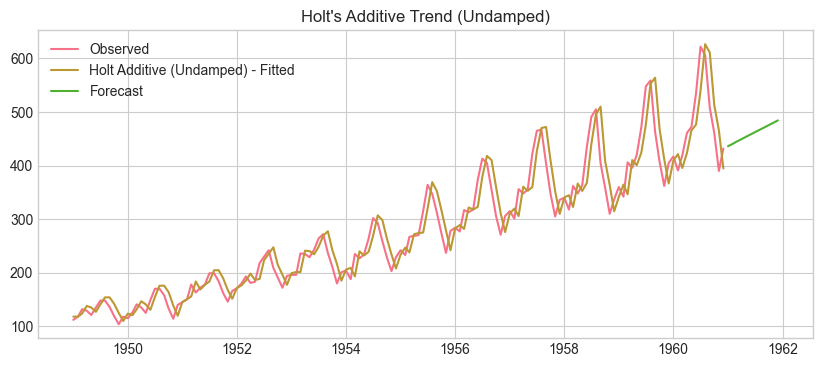

In [7]:
print("Holt's Additive Trend (Undamped)")

holt_add = Holt(air_passengers_series, exponential=False, damped=False).fit(optimized=True)
print(holt_add.summary())

holt_add_forecast = holt_add.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(air_passengers_series, label="Observed")
plt.plot(holt_add.fittedvalues, label="Holt Additive (Undamped) - Fitted")
plt.plot(holt_add_forecast, label="Forecast")
plt.legend()
plt.title("Holt's Additive Trend (Undamped)")
plt.show()

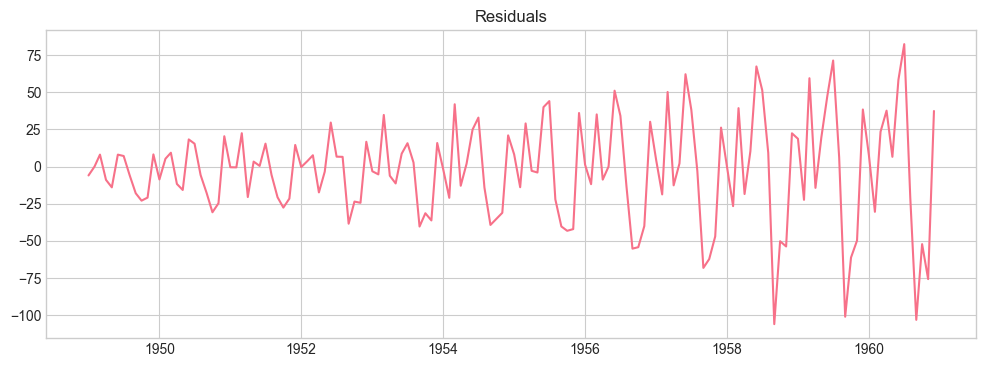

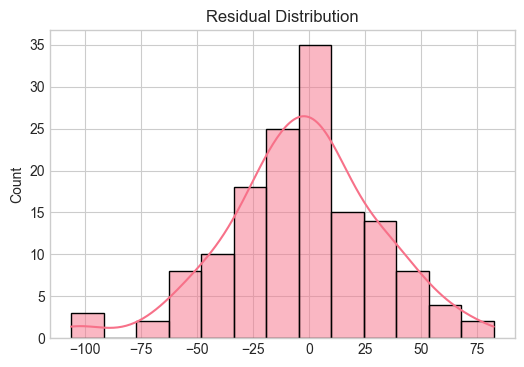

In [8]:
resid = holt_add.resid

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(resid, kde=True)
plt.title("Residual Distribution")
plt.show()

In [9]:
mse = mean_squared_error(air_passengers_series, holt_add.fittedvalues)
mae = mean_absolute_error(air_passengers_series, holt_add.fittedvalues)

print("MSE:", mse)
print("MAE:", mae)

MSE: 1140.0599833733431
MAE: 25.637491265255896


#### b. Holt's Additive Trend (Damped)
##### When to use:
* Trend exists but you expect it to flatten out.

Holt's Additive Trend (Damped)
                              Holt Model Results                              
Dep. Variable:                  value   No. Observations:                  144
Model:                           Holt   SSE                         162167.122
Optimized:                       True   AIC                           1021.826
Trend:                       Additive   BIC                           1036.675
Seasonal:                        None   AICC                          1022.650
Seasonal Periods:                None   Date:                 Sun, 07 Dec 2025
Box-Cox:                        False   Time:                         13:06:09
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
smoothing_trend      

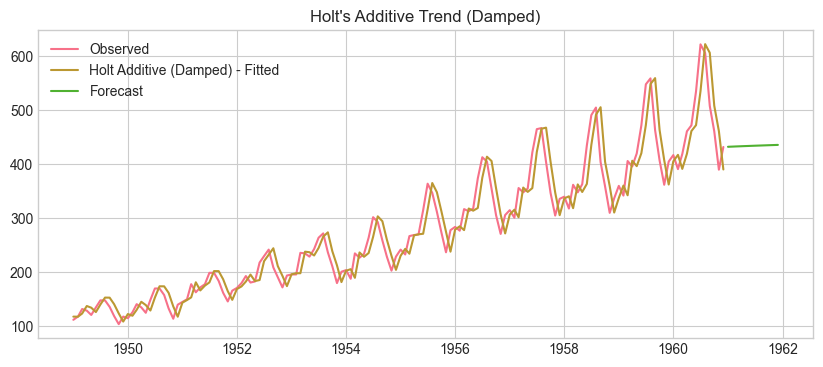

In [10]:
print("Holt's Additive Trend (Damped)")

holt_add_damped = Holt(air_passengers_series, exponential=False, damped=True).fit(optimized=True)
print(holt_add_damped.summary())

holt_add_damped_forecast = holt_add_damped.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(air_passengers_series, label="Observed")
plt.plot(holt_add_damped.fittedvalues, label="Holt Additive (Damped) - Fitted")
plt.plot(holt_add_damped_forecast, label="Forecast")
plt.legend()
plt.title("Holt's Additive Trend (Damped)")
plt.show()


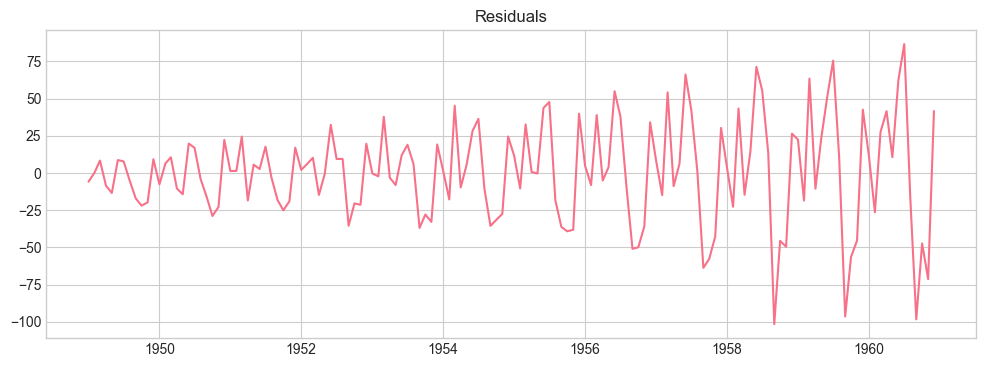

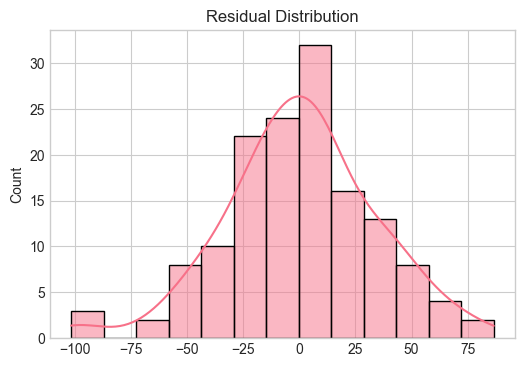

In [11]:
resid = holt_add_damped.resid

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(resid, kde=True)
plt.title("Residual Distribution")
plt.show()

In [12]:
mse = mean_squared_error(air_passengers_series, holt_add_damped.fittedvalues)
mae = mean_absolute_error(air_passengers_series, holt_add_damped.fittedvalues)

print("MSE:", mse)
print("MAE:", mae)

MSE: 1126.1605713139434
MAE: 25.630009028326196


#### c. Holt’s Exponential Trend Smoothing
##### When to use:
* Trend grows multiplicatively (common in economic and population data).

Holt’s Exponential Trend Model
                              Holt Model Results                              
Dep. Variable:                  value   No. Observations:                  144
Model:                           Holt   SSE                         172667.249
Optimized:                       True   AIC                           1028.860
Trend:                 Multiplicative   BIC                           1040.740
Seasonal:                        None   AICC                          1029.474
Seasonal Periods:                None   Date:                 Sun, 07 Dec 2025
Box-Cox:                        False   Time:                         13:06:11
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9949731                alpha                 True
smoothing_trend      

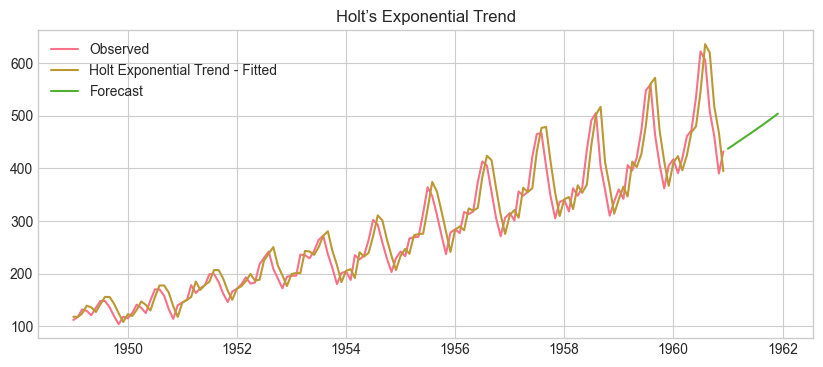

In [13]:
print("Holt’s Exponential Trend Model")

holt_exp = Holt(air_passengers_series, exponential=True, damped=False).fit(optimized=True)
print(holt_exp.summary())

holt_exp_forecast = holt_exp.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(air_passengers_series, label="Observed")
plt.plot(holt_exp.fittedvalues, label="Holt Exponential Trend - Fitted")
plt.plot(holt_exp_forecast, label="Forecast")
plt.legend()
plt.title("Holt’s Exponential Trend")
plt.show()


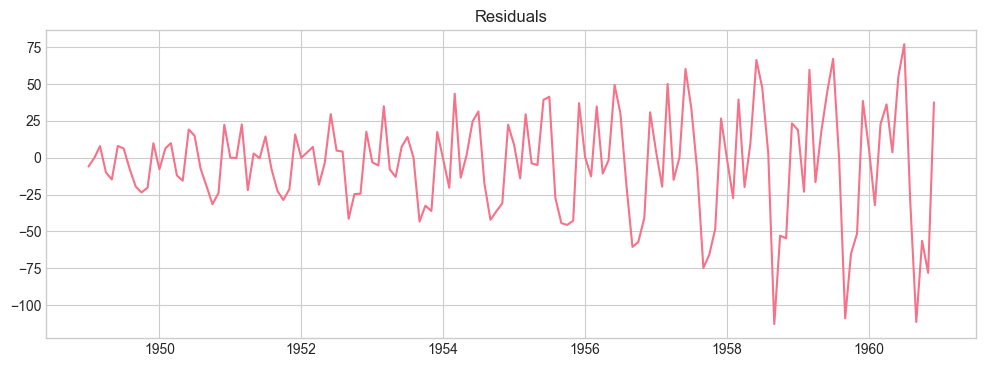

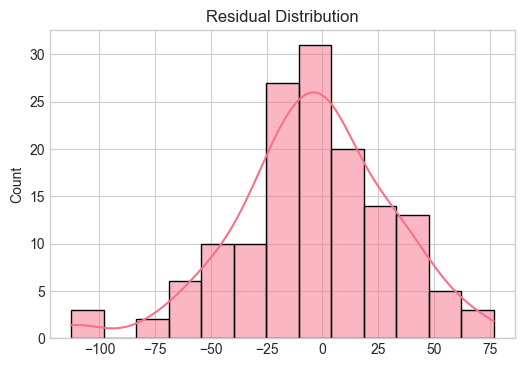

In [14]:
resid = holt_exp.resid

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(resid, kde=True)
plt.title("Residual Distribution")
plt.show()

In [15]:
mse = mean_squared_error(air_passengers_series, holt_exp.fittedvalues)
mae = mean_absolute_error(air_passengers_series, holt_exp.fittedvalues)

print("MSE:", mse)
print("MAE:", mae)

MSE: 1199.0781165331032
MAE: 26.18393176465133


### <span style="color:blue">03. Holt-Winters Seasonal Models

#### a. Holt-Winters Additive Seasonal Method
##### When to use:
* Seasonality does not grow in amplitude.

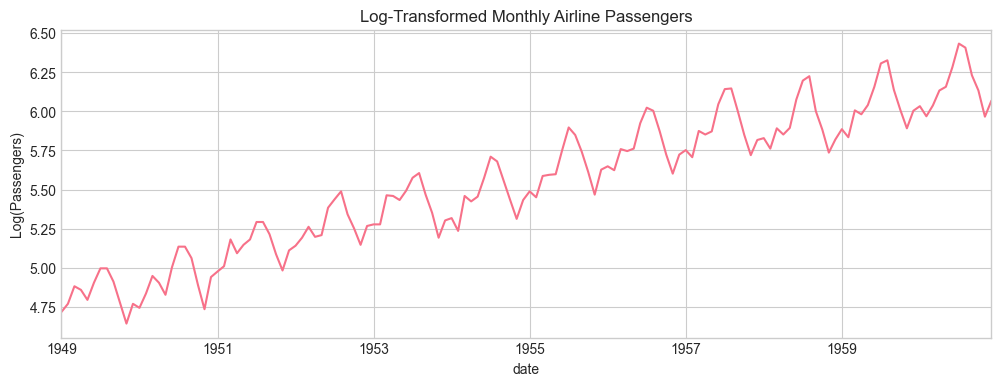

In [16]:
# Data shows increasing variance and likely multiplicative seasonality.
# For additive Holt-Winters, we often log-transform first.
air_passengers_series_log = np.log(air_passengers_series)

plt.figure(figsize=(12, 4))
air_passengers_series_log.plot(title='Log-Transformed Monthly Airline Passengers')
plt.ylabel('Log(Passengers)')
plt.grid(True)
plt.show()

In [17]:
# --- Instantiate and Fit Holt-Winters' Additive Seasonal Model (on log data) ---
print("\n--- Fitting Holt-Winters' Additive Seasonal Model (on log data) ---")
seasonal_periods = 12 # Annual seasonality for monthly data

# Fit Holt-Winters with additive trend and additive seasonality on log-transformed data
hw_add_model = ExponentialSmoothing(
    air_passengers_series_log,
    trend="add",
    seasonal="add",
    seasonal_periods=seasonal_periods,
    initialization_method="estimated"
)
hw_add_results = hw_add_model.fit(optimized=True)

print(hw_add_results.summary())

print("\nHolt-Winters Additive Model (on log data) Fitting Complete.")
print(f"Optimal smoothing_level (alpha): {hw_add_results.params.get('smoothing_level', 'N/A'):.4f}")
print(f"Optimal smoothing_trend (beta): {hw_add_results.params.get('smoothing_trend', 'N/A'):.4f}")
print(f"Optimal smoothing_seasonal (gamma): {hw_add_results.params.get('smoothing_seasonal', 'N/A'):.4f}")



--- Fitting Holt-Winters' Additive Seasonal Model (on log data) ---
                       ExponentialSmoothing Model Results                       
Dep. Variable:                    value   No. Observations:                  144
Model:             ExponentialSmoothing   SSE                              0.193
Optimized:                         True   AIC                           -920.894
Trend:                         Additive   BIC                           -873.377
Seasonal:                      Additive   AICC                          -915.422
Seasonal Periods:                    12   Date:                 Sun, 07 Dec 2025
Box-Cox:                          False   Time:                         13:06:14
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.377821

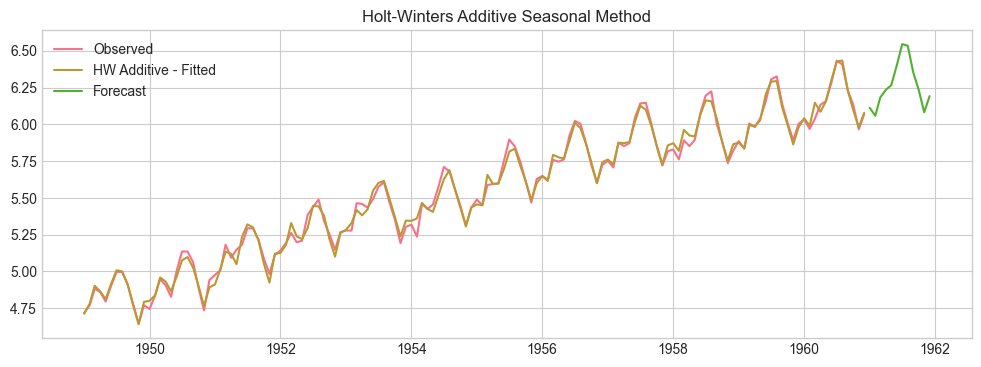

In [18]:
hw_add_forecast = hw_add_results.forecast(12)

plt.figure(figsize=(12,4))
plt.plot(air_passengers_series_log, label="Observed")
plt.plot(hw_add_results.fittedvalues, label="HW Additive - Fitted")
plt.plot(hw_add_forecast, label="Forecast")
plt.legend()
plt.title("Holt-Winters Additive Seasonal Method")
plt.show()

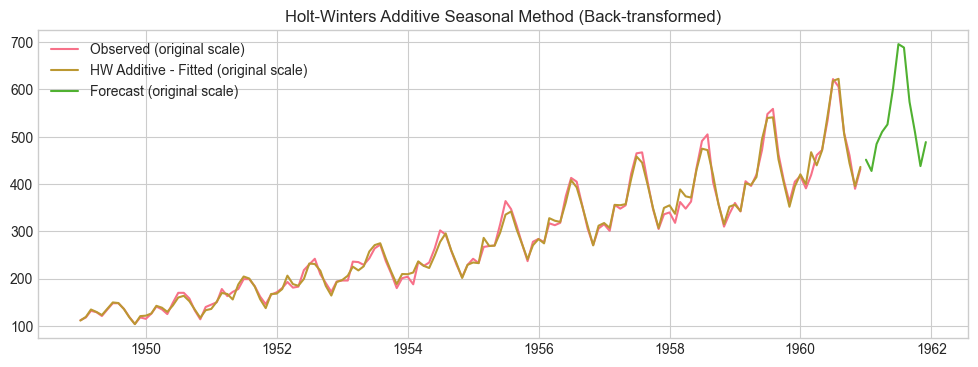

In [19]:
# Convert back to original scale
observed = np.exp(air_passengers_series_log)
fitted = np.exp(hw_add_results.fittedvalues)
forecast = np.exp(hw_add_forecast)

# Plot
plt.figure(figsize=(12,4))
plt.plot(observed, label="Observed (original scale)")
plt.plot(fitted, label="HW Additive - Fitted (original scale)")
plt.plot(forecast, label="Forecast (original scale)")
plt.legend()
plt.title("Holt-Winters Additive Seasonal Method (Back-transformed)")
plt.show()

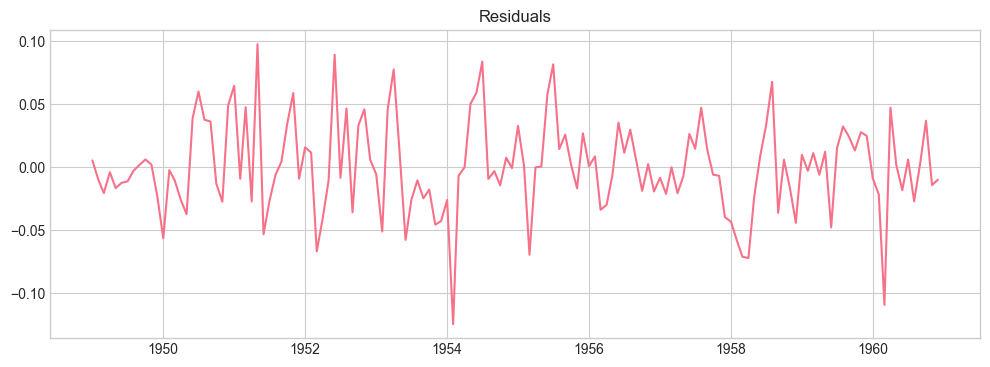

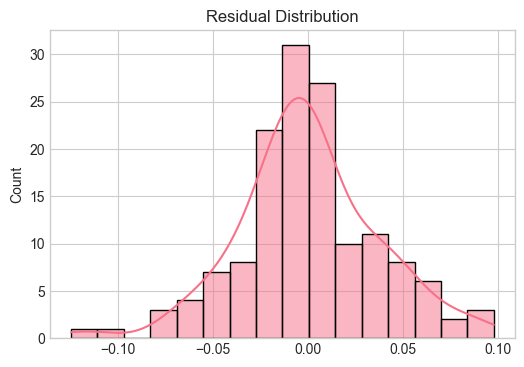

In [20]:
resid = hw_add_results.resid

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(resid, kde=True)
plt.title("Residual Distribution")
plt.show()

In [21]:
mse = mean_squared_error(air_passengers_series, np.exp(hw_add_results.fittedvalues))
mae = mean_absolute_error(air_passengers_series, np.exp(hw_add_results.fittedvalues))

print("MSE:", mse)
print("MAE:", mae)

MSE: 115.90054577959819
MAE: 7.551275167830021


#### b. Holt-Winters Multiplicative Seasonal Method
##### When to use:
* Seasonality grows proportionally to the level.

In [22]:
# --- Fitting Holt-Winters' Multiplicative Seasonal Model (on original data) ---
# This directly models multiplicative seasonality.
print("\n--- Fitting Holt-Winters' Multiplicative Seasonal Model (on original data) ---")
seasonal_periods = 12 # Annual seasonality for monthly data

hw_mul_model = ExponentialSmoothing(
    air_passengers_series, # Use original data
    trend="add",    # Assuming additive trend for the level component
    seasonal="mul", # Multiplicative seasonality
    seasonal_periods=seasonal_periods,
    initialization_method="estimated"
)

hw_mul_results = hw_mul_model.fit(optimized=True)

print(hw_mul_results.summary())

print("\nHolt-Winters Multiplicative Model Fitting Complete.")
print(f"Optimal smoothing_level (alpha): {hw_mul_results.params.get('smoothing_level', 'N/A'):.4f}")
print(f"Optimal smoothing_trend (beta): {hw_mul_results.params.get('smoothing_trend', 'N/A'):.4f}")
print(f"Optimal smoothing_seasonal (gamma): {hw_mul_results.params.get('smoothing_seasonal', 'N/A'):.4f}")



--- Fitting Holt-Winters' Multiplicative Seasonal Model (on original data) ---
                       ExponentialSmoothing Model Results                       
Dep. Variable:                    value   No. Observations:                  144
Model:             ExponentialSmoothing   SSE                          15952.885
Optimized:                         True   AIC                            709.892
Trend:                         Additive   BIC                            757.409
Seasonal:                Multiplicative   AICC                           715.364
Seasonal Periods:                    12   Date:                 Sun, 07 Dec 2025
Box-Cox:                          False   Time:                         13:06:18
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level            

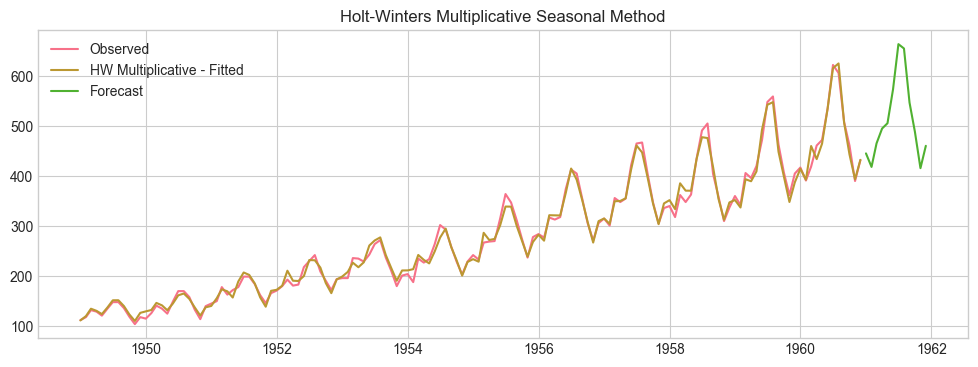

In [23]:
hw_mul_forecast = hw_mul_results.forecast(12)

plt.figure(figsize=(12,4))
plt.plot(air_passengers_series, label="Observed")
plt.plot(hw_mul_results.fittedvalues, label="HW Multiplicative - Fitted")
plt.plot(hw_mul_forecast, label="Forecast")
plt.legend()
plt.title("Holt-Winters Multiplicative Seasonal Method")
plt.show()

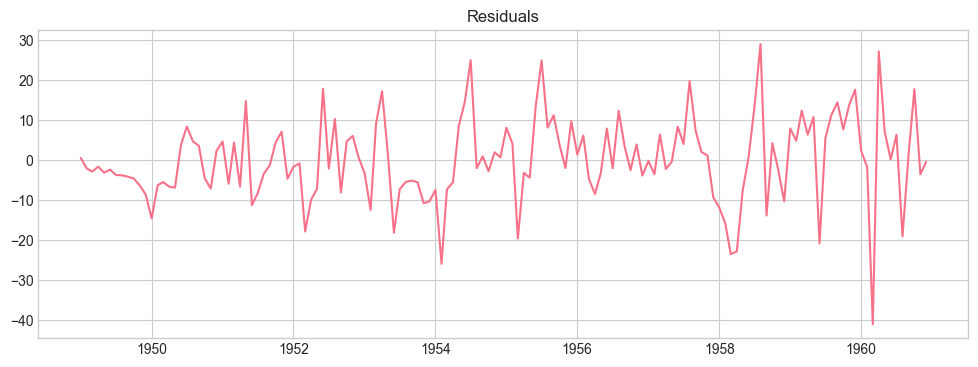

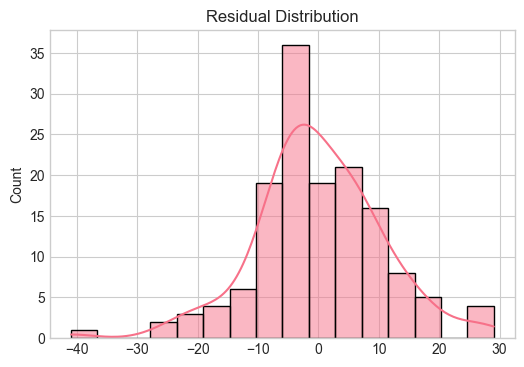

In [24]:
resid = hw_mul_results.resid

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(resid, kde=True)
plt.title("Residual Distribution")
plt.show()

In [25]:
mse = mean_squared_error(air_passengers_series, hw_mul_results.fittedvalues)
mae = mean_absolute_error(air_passengers_series, hw_mul_results.fittedvalues)

print("MSE:", mse)
print("MAE:", mae)

MSE: 110.78392220140296
MAE: 7.953084368854679
